In [1]:
import pandas as pd
import numpy as np
import ast

In [2]:
df = pd.read_csv("data/games_march2025_full.csv")

print("df.info")
print(df.info())
print("df.describe")
print(df.describe())
print("df.head")
print(df.head())

print(f"Före rengöring: {len(df)} rader")
print(f"Saknade värden:\n{df.isnull().sum()}")

df.info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94948 entries, 0 to 94947
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     94948 non-null  int64  
 1   name                      94946 non-null  object 
 2   release_date              94948 non-null  object 
 3   required_age              94948 non-null  int64  
 4   price                     94948 non-null  float64
 5   dlc_count                 94948 non-null  int64  
 6   detailed_description      89522 non-null  object 
 7   about_the_game            89499 non-null  object 
 8   short_description         89599 non-null  object 
 9   reviews                   10428 non-null  object 
 10  header_image              94948 non-null  object 
 11  website                   41194 non-null  object 
 12  support_url               44185 non-null  object 
 13  support_email             78848 non-null  object 
 14

In [3]:
#df_copy = df.copy()
#df_copy = (df_copy["detailed_description"].str.replace("â€™", "", regex=False))
# Vi har description-kolumner med mycket ogiltiga och skumma tecken i, droppar dom eftersom dom inte krävs för får undersökning. 
df = df.drop(columns=["detailed_description", "about_the_game", "short_description"])

#df_copy.to_excel("output.xlsx")

In [4]:
df.columns.tolist()

['appid',
 'name',
 'release_date',
 'required_age',
 'price',
 'dlc_count',
 'reviews',
 'header_image',
 'website',
 'support_url',
 'support_email',
 'windows',
 'mac',
 'linux',
 'metacritic_score',
 'metacritic_url',
 'achievements',
 'recommendations',
 'notes',
 'supported_languages',
 'full_audio_languages',
 'packages',
 'developers',
 'publishers',
 'categories',
 'genres',
 'screenshots',
 'movies',
 'user_score',
 'score_rank',
 'positive',
 'negative',
 'estimated_owners',
 'average_playtime_forever',
 'average_playtime_2weeks',
 'median_playtime_forever',
 'median_playtime_2weeks',
 'discount',
 'peak_ccu',
 'tags',
 'pct_pos_total',
 'num_reviews_total',
 'pct_pos_recent',
 'num_reviews_recent']

In [5]:
df["success"] = (
    (df["num_reviews_total"] >= 500) &
    (df["pct_pos_total"] >= 80)
).astype(int)


"""
# Filtrera bort spel med för få recensioner
df = df[df["num_reviews_total"] >= 10].copy()

# Definiera sedan framgång på de som är kvar
df["success"] = (df["pct_pos_total"] >= 85).astype(int)
"""


print("Klassfördelning:")
print(df["success"].value_counts())
print(f"Andel framgångsrika: {df['success'].mean():.1%}")

Klassfördelning:
success
0    88149
1     6799
Name: count, dtype: int64
Andel framgångsrika: 7.2%


In [6]:
# Feature engineering!
# ── CELL 3: Feature engineering ──────────────────────────────
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"]  = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month

df["num_supported_languages"] = df["supported_languages"].fillna("").str.split(",").str.len()
df["num_audio_languages"]     = df["full_audio_languages"].fillna("").str.split(",").str.len()
df["num_screenshots"]         = df["screenshots"].fillna("").str.split(",").str.len()
df["num_movies"]              = df["movies"].fillna("").str.split(",").str.len()

dev_counts = df["developers"].value_counts()
df["developer_experience"] = df["developers"].map(dev_counts).fillna(0)

# Genres
def parse_genres(val):
    try:
        return ast.literal_eval(val)
    except:
        return []

df["genres_parsed"] = df["genres"].fillna("[]").apply(parse_genres)
top_genres = df["genres_parsed"].explode().value_counts().head(15).index

genre_dummies = pd.DataFrame(
    {f"genre_{g}": df["genres_parsed"].apply(lambda x: int(g in x)) for g in top_genres}
)

# Tags
def parse_tags(val):
    try:
        return list(ast.literal_eval(val).keys())
    except:
        return []

df["tags_parsed"] = df["tags"].fillna("{}").apply(parse_tags)
top_tags = df["tags_parsed"].explode().value_counts().head(30).index

tag_dummies = pd.DataFrame(
    {f"tag_{t}": df["tags_parsed"].apply(lambda x: int(t in x)) for t in top_tags}
)

df = pd.concat([df, genre_dummies, tag_dummies], axis=1)

# ── CELL 4: Bygg X och y ─────────────────────────────────────
leak_cols = [
    "positive", "negative", "user_score", "score_rank",
    "pct_pos_total", "num_reviews_total", "pct_pos_recent",
    "num_reviews_recent", "peak_ccu", "recommendations",
    "average_playtime_forever", "average_playtime_2weeks",
    "median_playtime_forever", "median_playtime_2weeks",
]
drop_cols = [
    "appid", "name", "release_date", "header_image", "website",
    "support_url", "support_email", "metacritic_url", "notes",
    "packages", "reviews", "supported_languages",
    "full_audio_languages", "screenshots", "movies",
    "developers", "publishers", "categories", "genres", "tags",
    "genres_parsed", "tags_parsed",
] + leak_cols

def parse_owners(val):
    try:
        low, high = str(val).split(" - ")
        return (int(low.replace(",", "")) + int(high.replace(",", ""))) / 2
    except:
        return 0

df["estimated_owners"] = df["estimated_owners"].apply(parse_owners)

feature_cols = [c for c in df.columns if c not in drop_cols + ["success"]]
X = df[feature_cols].fillna(0)
y = df["success"]

print(f"Features: {len(feature_cols)}")
print(feature_cols)

Features: 62
['required_age', 'price', 'dlc_count', 'windows', 'mac', 'linux', 'metacritic_score', 'achievements', 'estimated_owners', 'discount', 'release_year', 'release_month', 'num_supported_languages', 'num_audio_languages', 'num_screenshots', 'num_movies', 'developer_experience', 'genre_Indie', 'genre_Casual', 'genre_Action', 'genre_Adventure', 'genre_Simulation', 'genre_Strategy', 'genre_RPG', 'genre_Early Access', 'genre_Free To Play', 'genre_Sports', 'genre_Racing', 'genre_Massively Multiplayer', 'genre_Utilities', 'genre_Design & Illustration', 'genre_Violent', 'tag_Indie', 'tag_Singleplayer', 'tag_Action', 'tag_Casual', 'tag_Adventure', 'tag_2D', 'tag_Simulation', 'tag_Strategy', 'tag_3D', 'tag_Puzzle', 'tag_Atmospheric', 'tag_RPG', 'tag_Colorful', 'tag_Pixel Graphics', 'tag_Story Rich', 'tag_Exploration', 'tag_Cute', 'tag_First-Person', 'tag_Arcade', 'tag_Fantasy', 'tag_Early Access', 'tag_Multiplayer', 'tag_Funny', 'tag_Horror', 'tag_Action-Adventure', 'tag_Retro', 'tag_Sh

In [7]:
print(df["tags"].dropna().iloc[0])
print("---")
print(df["genres"].dropna().iloc[0])

{'FPS': 90857, 'Shooter': 65397, 'Multiplayer': 62332, 'Competitive': 53359, 'Action': 47512, 'Team-Based': 46430, 'e-sports': 43533, 'Tactical': 41354, 'First-Person': 39414, 'PvP': 34470, 'Online Co-Op': 33966, 'Co-op': 30263, 'Strategy': 30111, 'Military': 28699, 'War': 28006, 'Difficult': 25966, 'Trading': 25717, 'Realistic': 25430, 'Fast-Paced': 25318, 'Moddable': 6603}
---
['Action', 'Free To Play']


Träning: 75958 rader
Test:    18990 rader

── Baseline (obeskuret) ──
Träddjup: 29
Antal löv: 3856
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     17630
           1       0.44      0.45      0.45      1360

    accuracy                           0.92     18990
   macro avg       0.70      0.70      0.70     18990
weighted avg       0.92      0.92      0.92     18990

AUC-ROC: 0.725

── Begränsat träd (max_depth=5) ──
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     17630
           1       0.63      0.47      0.54      1360

    accuracy                           0.94     18990
   macro avg       0.80      0.73      0.76     18990
weighted avg       0.94      0.94      0.94     18990

AUC-ROC: 0.891


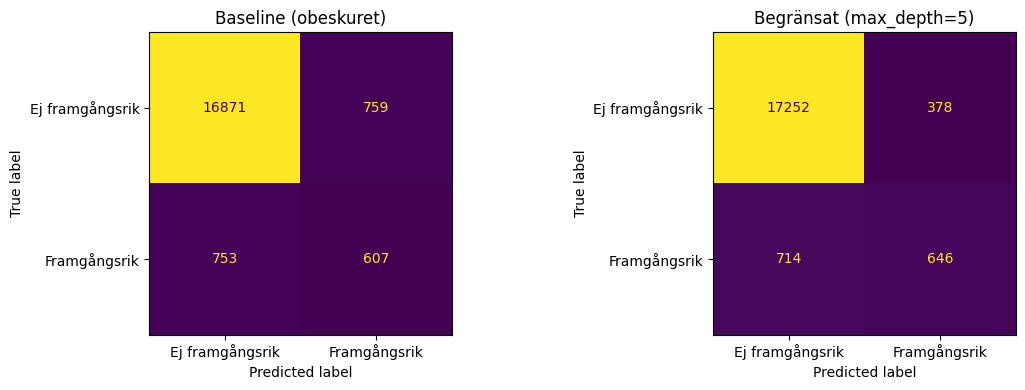

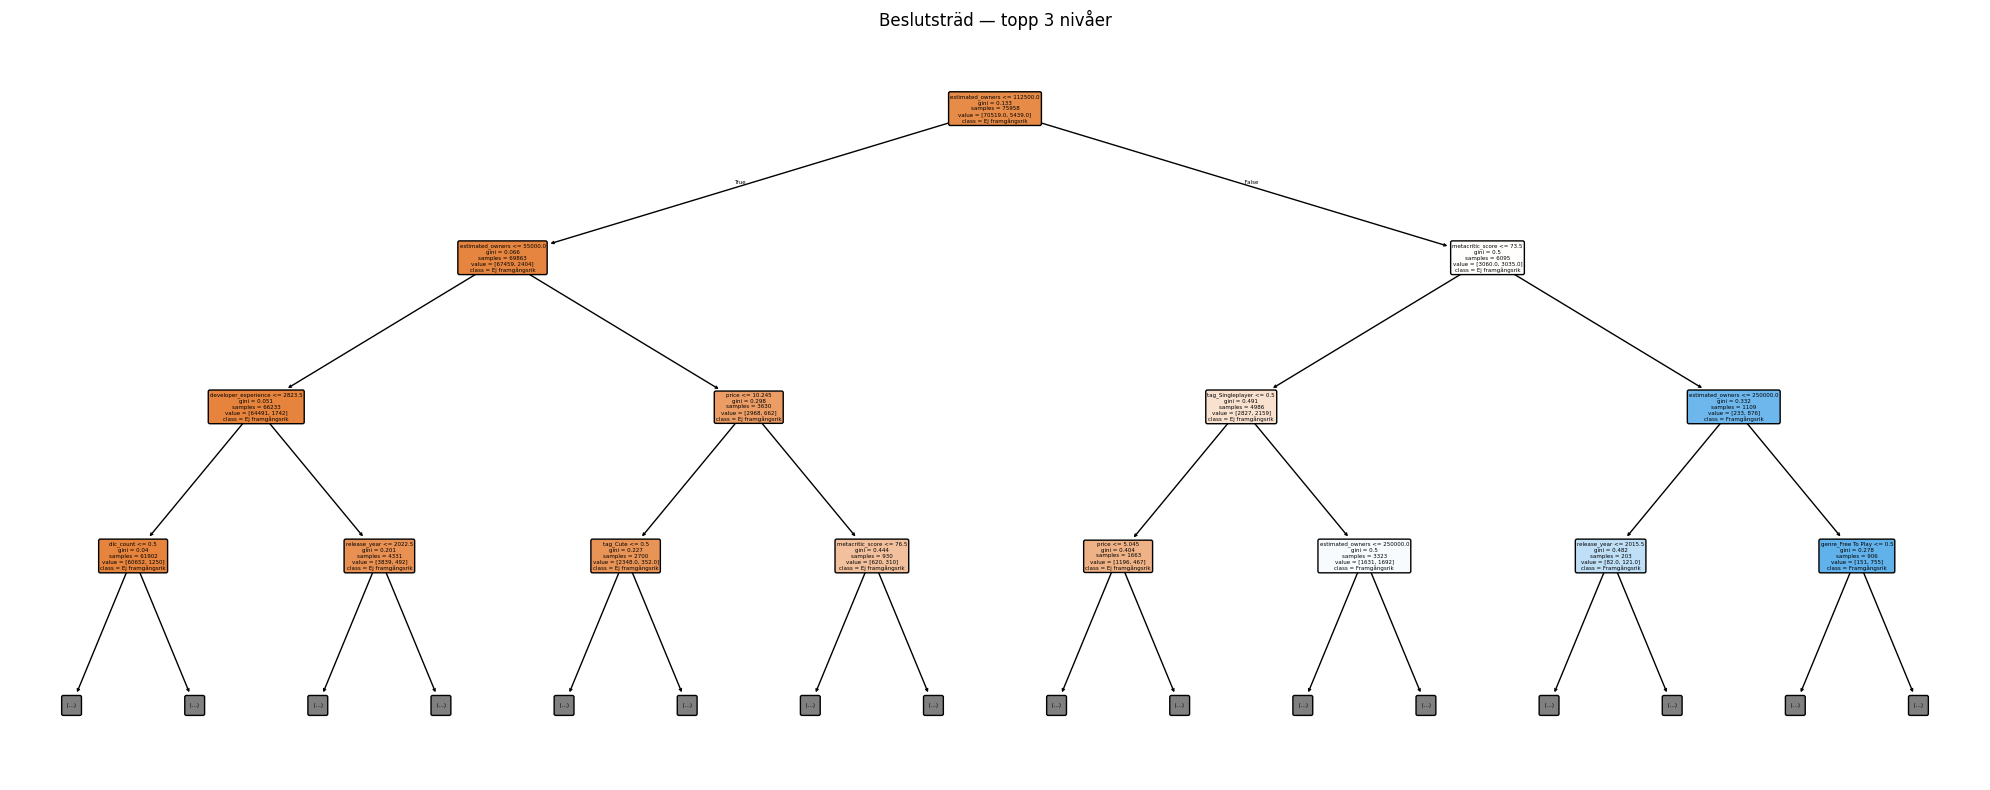

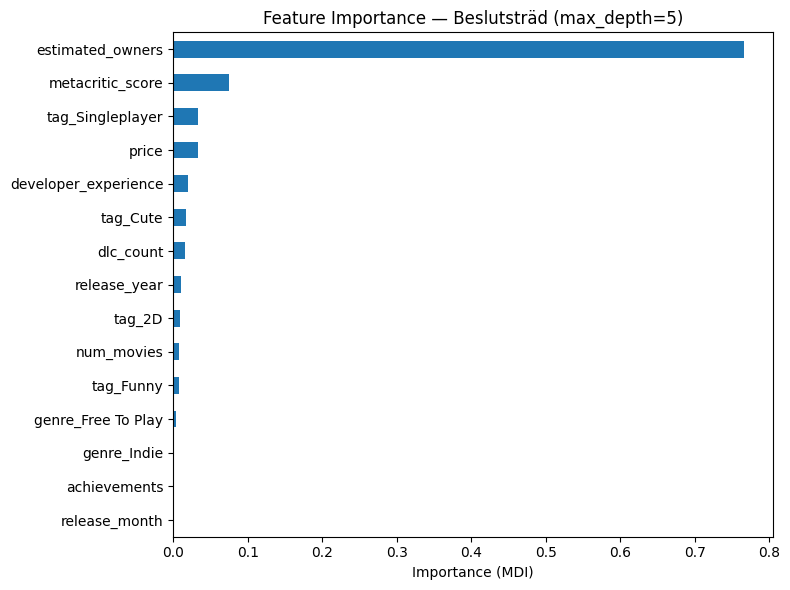

In [8]:
# Enkelt beslutsträd

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
import matplotlib.pyplot as plt

# ── SPLIT ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Träning: {X_train.shape[0]} rader")
print(f"Test:    {X_test.shape[0]} rader")

# ── BASELINE — obeskuret träd ────────────────────────────────
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)
y_pred_base = dt_baseline.predict(X_test)

print("\n── Baseline (obeskuret) ──")
print(f"Träddjup: {dt_baseline.get_depth()}")
print(f"Antal löv: {dt_baseline.get_n_leaves()}")
print(classification_report(y_test, y_pred_base))
print(f"AUC-ROC: {roc_auc_score(y_test, dt_baseline.predict_proba(X_test)[:,1]):.3f}")

# ── BEGRÄNSAT TRÄD — max_depth=5 ─────────────────────────────
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print("\n── Begränsat träd (max_depth=5) ──")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]):.3f}")

# ── CONFUSION MATRIX ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, model, title in zip(
    axes,
    [dt_baseline, dt],
    ["Baseline (obeskuret)", "Begränsat (max_depth=5)"]
):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=["Ej framgångsrik", "Framgångsrik"],
        ax=ax, colorbar=False
    )
    ax.set_title(title)
plt.tight_layout()
plt.show()

# ── VISUALISERA TRÄDET (max_depth=5) ─────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=["Ej framgångsrik", "Framgångsrik"],
    filled=True, rounded=True,
    max_depth=3,   # visa bara topp 3 nivåer för läsbarhet
    ax=ax
)
plt.title("Beslutsträd — topp 3 nivåer")
plt.tight_layout()
fig.savefig("beslutstrad.png", dpi=150, bbox_inches="tight")
plt.show()

# ── FEATURE IMPORTANCE ───────────────────────────────────────
importances = pd.Series(dt.feature_importances_, index=feature_cols)
top15 = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
top15.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Feature Importance — Beslutsträd (max_depth=5)")
ax.set_xlabel("Importance (MDI)")
plt.tight_layout()
plt.show()

In [9]:
# Estimated owners är den viktigaste variabeln enligt trädet,
# Men estimated owners är nog snarare en effekt av popularitet och inte förklaringen till det.
# Lutar åt dataläckage, låt oss ta bort variabeln och se.

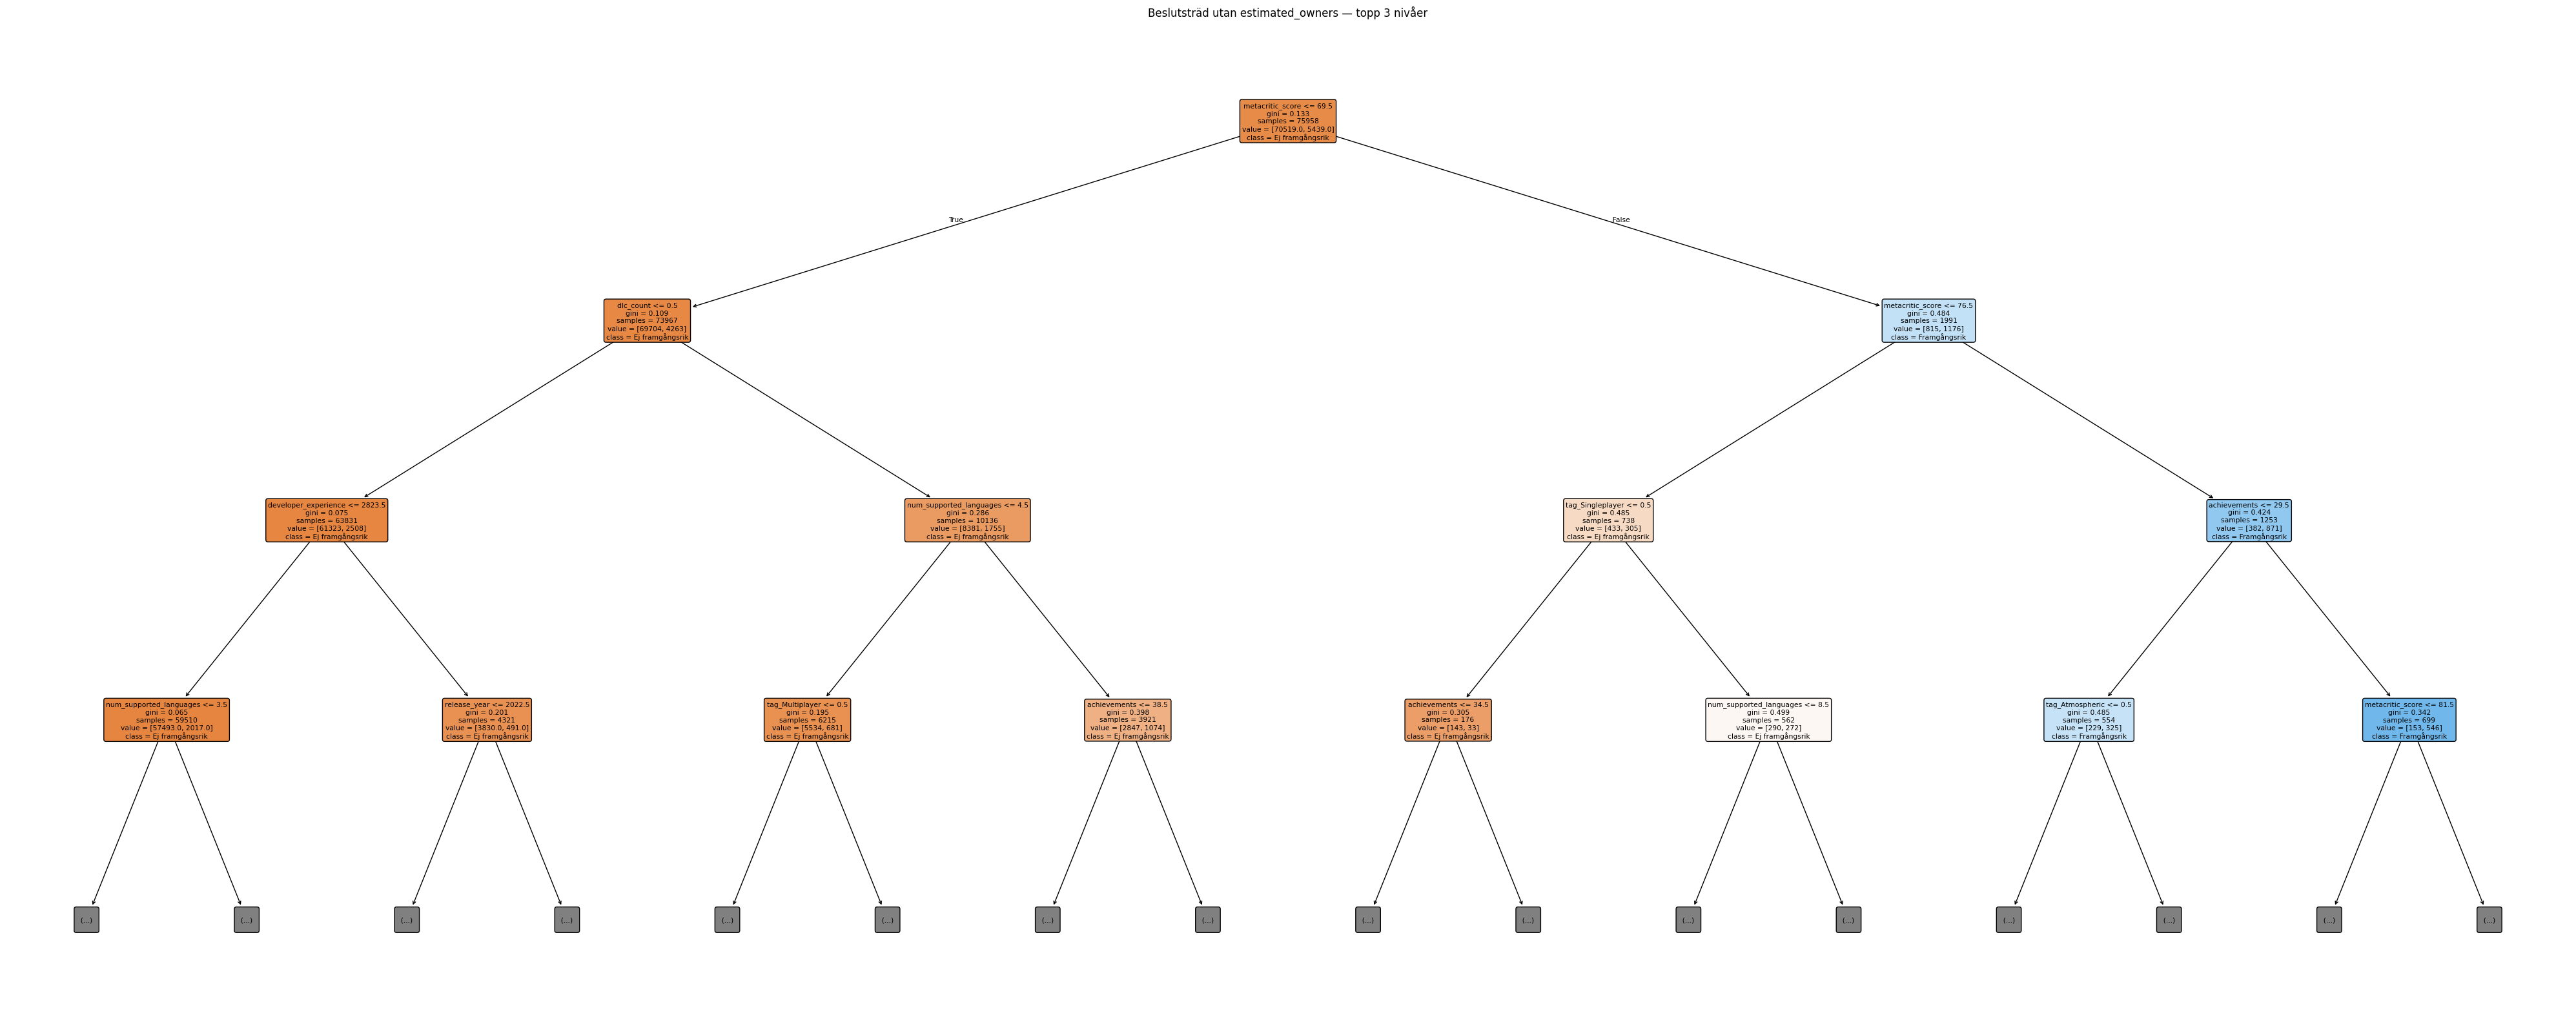

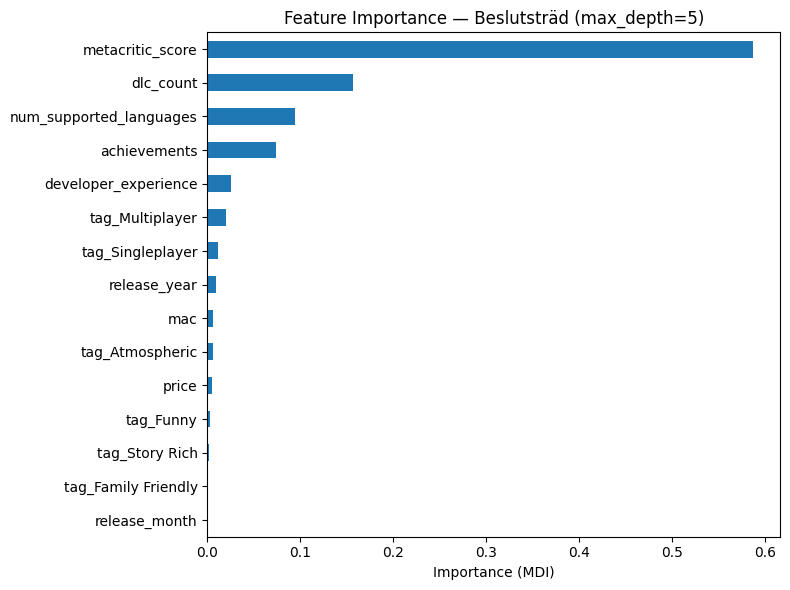

In [10]:
feature_cols_no_owners = [c for c in feature_cols if c != "estimated_owners"]

X_no = df[feature_cols_no_owners].fillna(0)

X_train_no, X_test_no, y_train_no, y_test_no = train_test_split(
    X_no, y, test_size=0.2, random_state=42, stratify=y
)

dt_no = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_no.fit(X_train_no, y_train_no)

fig, ax = plt.subplots(figsize=(40, 16))
plot_tree(
    dt_no,
    feature_names=feature_cols_no_owners,
    class_names=["Ej framgångsrik", "Framgångsrik"],
    filled=True, rounded=True,
    max_depth=3,
    ax=ax
)
plt.title("Beslutsträd utan estimated_owners — topp 3 nivåer")
plt.tight_layout()
fig.savefig("beslutstrad_no_owners.png", dpi=150, bbox_inches="tight")
plt.show()

# ── FEATURE IMPORTANCE ───────────────────────────────────────
importances = pd.Series(dt_no.feature_importances_, index=feature_cols_no_owners)
top15 = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
top15.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Feature Importance — Beslutsträd (max_depth=5)")
ax.set_xlabel("Importance (MDI)")
plt.tight_layout()
plt.show()

In [11]:
"""
Rotnod: metacritic_score <= 69.5 — Metacritic-betyget är den viktigaste variabeln när estimated_owners tas bort. 
Det är ett rimligt resultat och inte dataläckage — betyget sätts av kritiker och speglar kvalitet.

En viktig observation: höger gren har bara 1 001 spel — de flesta spel i datasetet har inget Metacritic-betyg alls (värdet är 0 eller saknas). Det betyder att trädet i praktiken sorterar bort 94% av spelen i första steget baserat på om de ens har ett betyg. 

"""



'\nRotnod: metacritic_score <= 69.5 — Metacritic-betyget är den viktigaste variabeln när estimated_owners tas bort. \nDet är ett rimligt resultat och inte dataläckage — betyget sätts av kritiker och speglar kvalitet.\n\nEn viktig observation: höger gren har bara 1 001 spel — de flesta spel i datasetet har inget Metacritic-betyg alls (värdet är 0 eller saknas). Det betyder att trädet i praktiken sorterar bort 94% av spelen i första steget baserat på om de ens har ett betyg. \n\n'

In [12]:
# Classification report
y_pred_no = dt_no.predict(X_test_no)

print(classification_report(y_test_no, y_pred_no))
print(f"AUC-ROC: {roc_auc_score(y_test_no, dt_no.predict_proba(X_test_no)[:,1]):.3f}")

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     17630
           1       0.65      0.20      0.30      1360

    accuracy                           0.93     18990
   macro avg       0.80      0.60      0.63     18990
weighted avg       0.92      0.93      0.92     18990

AUC-ROC: 0.803


In [13]:
# Kom ihåg att setet är kraftigt snedfördelat! Accuracy är inte att förlita sig på här.
"""
Precision 0.65 — när modellen säger "framgångsrik" har den rätt 65% av gångerna
Recall 0.20 — men den hittar bara 20% av alla framgångsrika spel, missar 80%
F1 0.30 — svagt

AUC-ROC 0.803 är ganska bra — det betyder att modellen rangordnar framgångsrika spel över ej framgångsrika i 80% av fallen, även om den är dålig på att sätta ett konkret ja/nej-beslut.
"""

'\nPrecision 0.65 — när modellen säger "framgångsrik" har den rätt 65% av gångerna\nRecall 0.20 — men den hittar bara 20% av alla framgångsrika spel, missar 80%\nF1 0.30 — svagt\n\nAUC-ROC 0.803 är ganska bra — det betyder att modellen rangordnar framgångsrika spel över ej framgångsrika i 80% av fallen, även om den är dålig på att sätta ett konkret ja/nej-beslut.\n'

In [14]:
# Vi kan prova fixa med att lägga till "balanced"-parametern.

dt_weighted = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)
dt_weighted.fit(X_train_no, y_train_no)
y_pred_w = dt_weighted.predict(X_test_no)

print(classification_report(y_test_no, y_pred_w))
print(f"AUC-ROC: {roc_auc_score(y_test_no, dt_weighted.predict_proba(X_test_no)[:,1]):.3f}")

              precision    recall  f1-score   support

           0       0.97      0.81      0.88     17630
           1       0.21      0.67      0.32      1360

    accuracy                           0.80     18990
   macro avg       0.59      0.74      0.60     18990
weighted avg       0.92      0.80      0.84     18990

AUC-ROC: 0.815


In [15]:
# RANDOM FOREST START

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance

# ── CROSS VALIDATION & GRID SEARCH ──────────────────────────
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 20],
    "min_samples_split": [2, 10],
    "max_features": ["sqrt", "log2"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

rf_grid.fit(X_train_no, y_train_no)

print(f"Bästa parametrar: {rf_grid.best_params_}")
print(f"Bästa CV F1-score: {rf_grid.best_score_:.3f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Bästa parametrar: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Bästa CV F1-score: 0.396


              precision    recall  f1-score   support

           0       0.97      0.85      0.91     17630
           1       0.26      0.71      0.38      1360

    accuracy                           0.84     18990
   macro avg       0.62      0.78      0.64     18990
weighted avg       0.92      0.84      0.87     18990

AUC-ROC: 0.877


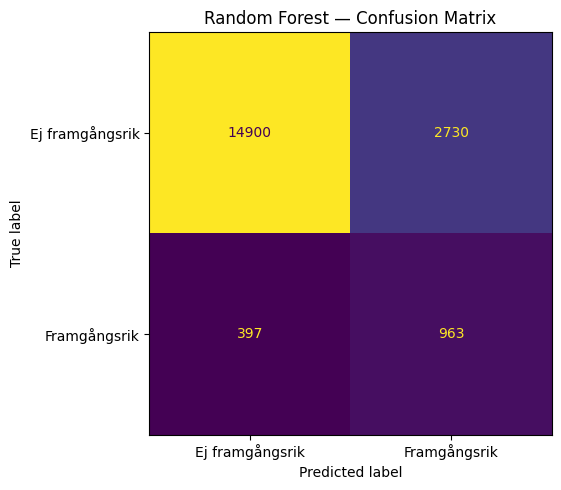

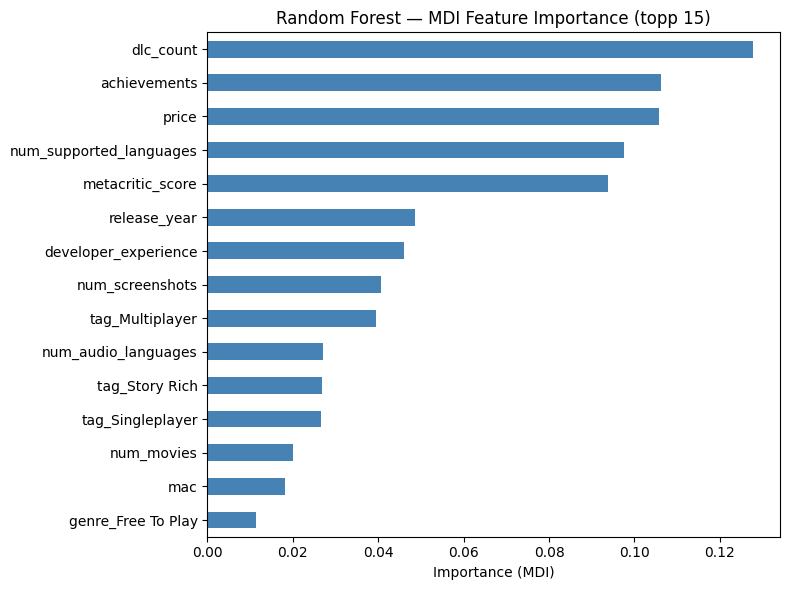

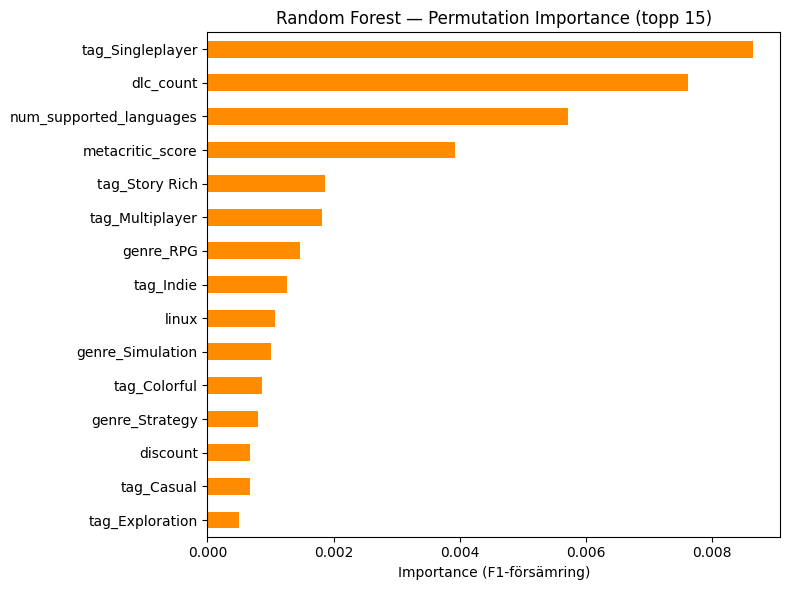

In [17]:
# ── UTVÄRDERING ──────────────────────────────────────────────
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test_no)

print(classification_report(y_test_no, y_pred_rf))
print(f"AUC-ROC: {roc_auc_score(y_test_no, rf_best.predict_proba(X_test_no)[:,1]):.3f}")

# ── CONFUSION MATRIX ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    rf_best, X_test_no, y_test_no,
    display_labels=["Ej framgångsrik", "Framgångsrik"],
    ax=ax, colorbar=False
)
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
fig.savefig("rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── MDI FEATURE IMPORTANCE ───────────────────────────────────
mdi = pd.Series(rf_best.feature_importances_, index=feature_cols_no_owners)
top15_mdi = mdi.nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
top15_mdi.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Random Forest — MDI Feature Importance (topp 15)")
ax.set_xlabel("Importance (MDI)")
plt.tight_layout()
fig.savefig("rf_mdi_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# ── PERMUTATION IMPORTANCE ───────────────────────────────────
perm = permutation_importance(
    rf_best, X_test_no, y_test_no,
    n_repeats=10, random_state=42, n_jobs=-1, scoring="f1"
)

perm_series = pd.Series(perm.importances_mean, index=feature_cols_no_owners)
top15_perm = perm_series.nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
top15_perm.sort_values().plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Random Forest — Permutation Importance (topp 15)")
ax.set_xlabel("Importance (F1-försämring)")
plt.tight_layout()
fig.savefig("rf_perm_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# XGBoost START

In [19]:
from xgboost import XGBClassifier

# ── BERÄKNA scale_pos_weight ─────────────────────────────────
neg = (y_train_no == 0).sum()
pos = (y_train_no == 1).sum()
scale = neg / pos
print(f"scale_pos_weight: {scale:.1f}")

# ── SPLIT FÖR EARLY STOPPING (train → train + val) ───────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_no, y_train_no,
    test_size=0.1, random_state=42, stratify=y_train_no
)

# ── GRID SEARCH ──────────────────────────────────────────────
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "alpha": [0, 1],       # L1
    "lambda": [1, 5],      # L2
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale,
    early_stopping_rounds=20,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
)

xgb_grid = GridSearchCV(
    xgb_base,
    param_grid_xgb,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

xgb_grid.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f"Bästa parametrar: {xgb_grid.best_params_}")
print(f"Bästa CV F1-score: {xgb_grid.best_score_:.3f}")

scale_pos_weight: 13.0
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Bästa parametrar: {'alpha': 0, 'lambda': 1, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200}
Bästa CV F1-score: 0.393


              precision    recall  f1-score   support

           0       0.98      0.82      0.89     17630
           1       0.25      0.79      0.38      1360

    accuracy                           0.81     18990
   macro avg       0.62      0.80      0.64     18990
weighted avg       0.93      0.81      0.85     18990

AUC-ROC: 0.890


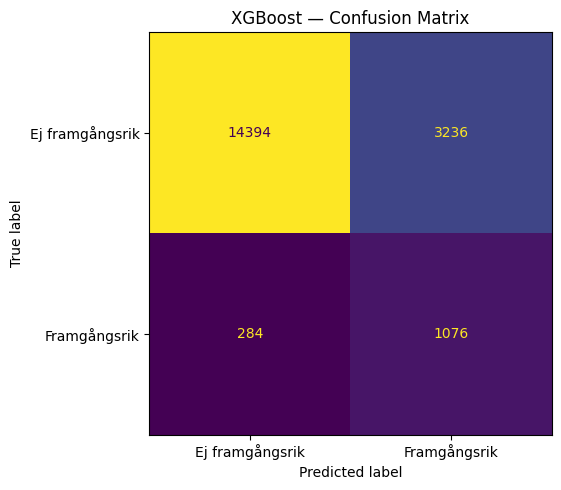

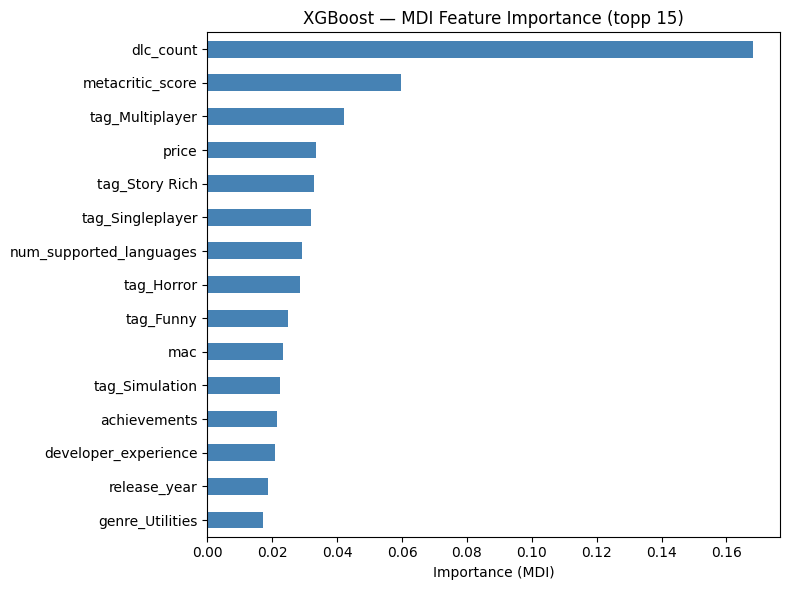

In [ ]:
# ── UTVÄRDERING ──────────────────────────────────────────────
xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_test_no)

print(classification_report(y_test_no, y_pred_xgb))
print(f"AUC-ROC: {roc_auc_score(y_test_no, xgb_best.predict_proba(X_test_no)[:,1]):.3f}")

# ── CONFUSION MATRIX ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    xgb_best, X_test_no, y_test_no,
    display_labels=["Ej framgångsrik", "Framgångsrik"],
    ax=ax, colorbar=False
)
plt.title("XGBoost — Confusion Matrix")
plt.tight_layout()
fig.savefig("xgb_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── MDI FEATURE IMPORTANCE ───────────────────────────────────
mdi_xgb = pd.Series(xgb_best.feature_importances_, index=feature_cols_no_owners)
top15_mdi_xgb = mdi_xgb.nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
top15_mdi_xgb.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("XGBoost — MDI Feature Importance (topp 15)")
ax.set_xlabel("Importance (MDI)")
plt.tight_layout()
fig.savefig("xgb_mdi_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# ── PERMUTATION IMPORTANCE ───────────────────────────────────
perm_xgb = permutation_importance(
    xgb_best, X_test_no, y_test_no,
    n_repeats=10, random_state=42, n_jobs=-1, scoring="f1"
)

perm_xgb_series = pd.Series(perm_xgb.importances_mean, index=feature_cols_no_owners)
top15_perm_xgb = perm_xgb_series.nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
top15_perm_xgb.sort_values().plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("XGBoost — Permutation Importance (topp 15)")
ax.set_xlabel("Importance (F1-försämring)")
plt.tight_layout()
fig.savefig("xgb_perm_importance.png", dpi=150, bbox_inches="tight")
plt.show()